Save directory: C:\Users\Jianpeng Chen\Desktop\TUD 2025\MR\Ubermag\skyrmion\20260430_03
Mesh: [256 256   1] cells  |  pixel size: 5 nm
Running OOMMF (ExeOOMMFRunner)[2026-04-30T10:18:50]... (8.1 s)
Relaxation done.
Mz range: -580000.0 ~ 580000.0 A/m
Array shape: (256, 256)


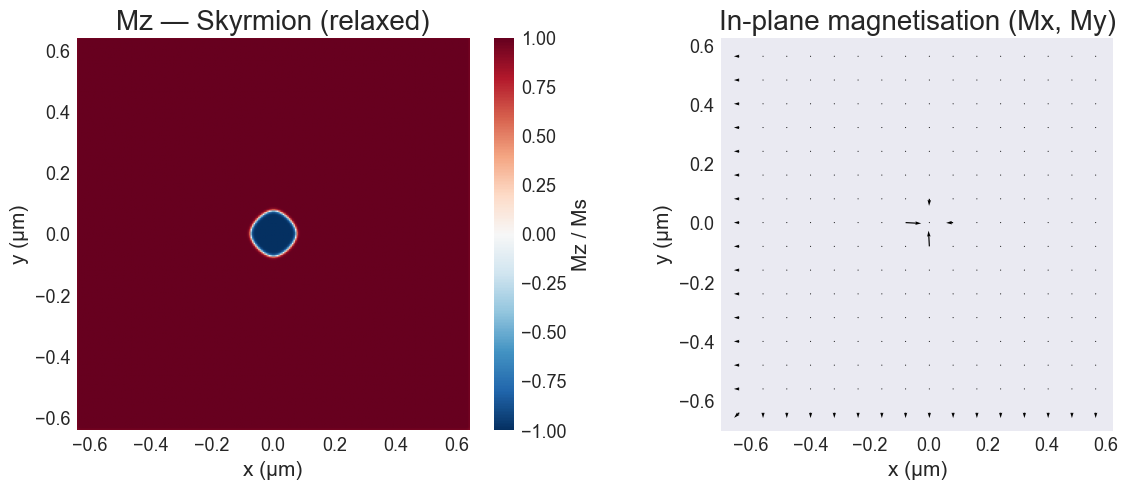

Bz range at 50 nm: 96.345 ~ 363.865 mT
Mz min: -579999.9821905352 max: 579999.9999999966
Bz min: 96.34506417458155 mT
Bz max: 363.8653884595206 mT
Bz mean: 356.9518715467268 mT
Bz at center (mT): 96.34506417458155
Bz at edge (mT): 363.8653884595206


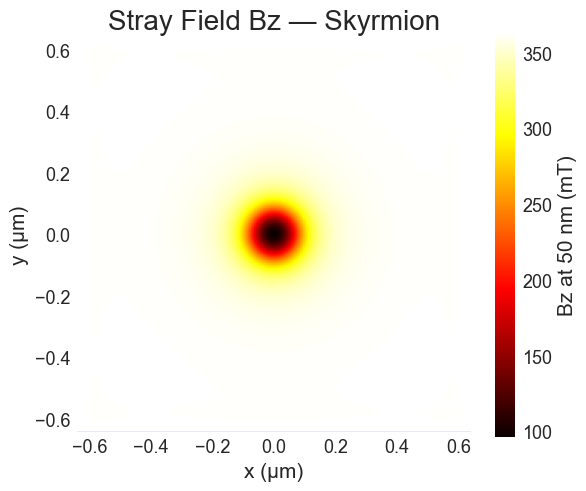

Saved:
  C:\Users\Jianpeng Chen\Desktop\TUD 2025\MR\Ubermag\skyrmion\20260430_03/Bz_NV_skyrmion.npy   shape=(256, 256)
  C:\Users\Jianpeng Chen\Desktop\TUD 2025\MR\Ubermag\skyrmion\20260430_03/Mz_true_skyrmion.npy  shape=(256, 256)
JSON saved.

=== Pipeline integration check ===
Bz_NV shape : (256, 256)  (expected (256, 256))
Mz_true shape: (256, 256)  (expected (256, 256))
Bz_NV dtype : float64
Mz_true dtype: float64

Replace in your Notebook Cell 2:
  Bz_NV = np.load(r"C:\Users\Jianpeng Chen\Desktop\TUD 2025\MR\Ubermag\skyrmion\20260430_03/Bz_NV_skyrmion.npy")
  Mz_true = np.load(r"C:\Users\Jianpeng Chen\Desktop\TUD 2025\MR\Ubermag\skyrmion\20260430_03/Mz_true_skyrmion.npy")


In [1]:
# ============================================================
# Ubermag Skyrmion Simulation — Google Colab
# Single centered Néel skyrmion, OOP background
# Output: Bz_NV_skyrmion.npy, Mz_true_skyrmion.npy
# Compatible with Ubermag_Model_Verification pipeline
# ============================================================
# Author: Yue Yu, TU Dresden / ct.qmat
# ============================================================

# ── Cell 1: Install & Mount ──────────────────────────────────
# (run manually if needed)

# ── Cell 2: Imports ──────────────────────────────────────────
import discretisedfield as df
import micromagneticmodel as mm
import oommfc as oc
import numpy as np
import matplotlib.pyplot as plt
import json, os
from datetime import datetime

# ── Cell 3: Paths ────────────────────────────────────────────
CASE     = "skyrmion"
base_dir = r"C:\Users\Jianpeng Chen\Desktop\TUD 2025\MR\Ubermag"

date_str = datetime.now().strftime("%Y%m%d")
idx = 1
while os.path.exists(os.path.join(base_dir, CASE, f"{date_str}_{idx:02d}")):
    idx += 1

case_dir = os.path.join(base_dir, CASE, f"{date_str}_{idx:02d}")
os.makedirs(case_dir, exist_ok=True)
print("Save directory:", case_dir)

# ── Cell 4: Geometry ─────────────────────────────────────────
Lx   = 256 * 5e-9
Ly   = 256 * 5e-9
Lz   = 5e-9
cell = (5e-9, 5e-9, 5e-9)
z_NV = 50e-9

mesh = df.Mesh(
    p1=(-Lx/2, -Ly/2, 0),
    p2=( Lx/2,  Ly/2, Lz),
    cell=cell
)
print(f"Mesh: {mesh.n} cells  |  pixel size: {cell[0]*1e9:.0f} nm")

# ── Cell 5: Material parameters ──────────────────────────────
Ms = 5.8e5
A  = 1.5e-11
D  = 3.0e-3
K  = 0.8e6

# ── Cell 6: Initial magnetisation ────────────────────────────
r0 = 80e-9
w  = 30e-9

def m_skyrmion(pos):
    x, y, _ = pos
    r   = np.sqrt(x**2 + y**2)
    mz  = np.tanh((r - r0) / w)
    mxy = np.sqrt(max(1.0 - mz**2, 0.0))
    phi = np.arctan2(y, x)
    mx  = mxy * np.cos(phi)
    my  = mxy * np.sin(phi)
    return (mx * Ms, my * Ms, mz * Ms)

# ── Cell 7: Build system & relax ─────────────────────────────
system = mm.System(name="skyrmion")
system.energy = (
    mm.Exchange(A=A)
    + mm.DMI(D=D, crystalclass="Cnv_z")
    + mm.UniaxialAnisotropy(K=K, u=(0, 0, 1))
    + mm.Demag()
)
system.m = df.Field(mesh, nvdim=3, value=m_skyrmion, norm=Ms)

md = oc.MinDriver()
md.drive(system)
print("Relaxation done.")

# ── Cell 8: Extract Mx, My, Mz ───────────────────────────────
m_sel = system.m.sel(z=Lz / 2)
Mx = np.squeeze(m_sel.x.array)
My = np.squeeze(m_sel.y.array)
Mz = np.squeeze(m_sel.z.array)
print(f"Mz range: {Mz.min():.1f} ~ {Mz.max():.1f} A/m")
print(f"Array shape: {Mz.shape}")

# ── Cell 9: Plot Mz ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(
    Mz / Ms,
    extent=[-Lx/2*1e6, Lx/2*1e6, -Ly/2*1e6, Ly/2*1e6],
    origin="lower", cmap="RdBu_r", vmin=-1, vmax=1
)
plt.colorbar(im0, ax=axes[0], label="Mz / Ms")
axes[0].set_title("Mz — Skyrmion (relaxed)")
axes[0].set_xlabel("x (µm)")
axes[0].set_ylabel("y (µm)")

step = 16
nx, ny = Mz.shape
x_arr = np.linspace(-Lx/2*1e6, Lx/2*1e6, nx)
y_arr = np.linspace(-Ly/2*1e6, Ly/2*1e6, ny)
X, Y  = np.meshgrid(x_arr[::step], y_arr[::step], indexing="ij")
axes[1].quiver(X, Y,
               Mx[::step, ::step] / Ms,
               My[::step, ::step] / Ms,
               scale=20, width=0.003)
axes[1].set_aspect("equal")
axes[1].set_title("In-plane magnetisation (Mx, My)")
axes[1].set_xlabel("x (µm)")
axes[1].set_ylabel("y (µm)")

plt.tight_layout()
plt.savefig(os.path.join(case_dir, "Mz_skyrmion.png"), dpi=150)
plt.show()

# ── Cell 10: Compute Bz stray field ──────────────────────────
dx = cell[0]
dy = cell[1]
kx_arr  = 2 * np.pi * np.fft.fftfreq(nx, d=dx)
ky_arr  = 2 * np.pi * np.fft.fftfreq(ny, d=dy)
kx_grid, ky_grid = np.meshgrid(kx_arr, ky_arr, indexing="ij")
k = np.sqrt(kx_grid**2 + ky_grid**2)
k[0, 0] = 1e-12

Mx_k = np.fft.fft2(Mx)
My_k = np.fft.fft2(My)
Mz_k = np.fft.fft2(Mz)

mu0 = 4 * np.pi * 1e-7
Bz_k = mu0 / (2 * k) * (
    -1j * kx_grid * Mx_k
    - 1j * ky_grid * My_k
    + k * Mz_k
)

Bz_NV = np.real(np.fft.ifft2(Bz_k * np.exp(-k * z_NV)))
print(f"Bz range at {z_NV*1e9:.0f} nm: "
      f"{Bz_NV.min()*1e3:.3f} ~ {Bz_NV.max()*1e3:.3f} mT")

print("Mz min:", Mz.min(), "max:", Mz.max())
print("Bz min:", Bz_NV.min()*1e3, "mT")
print("Bz max:", Bz_NV.max()*1e3, "mT")
print("Bz mean:", Bz_NV.mean()*1e3, "mT")

# 看 skyrmion 核心位置的 Bz
center = 128
print("Bz at center (mT):", Bz_NV[center, center]*1e3)
print("Bz at edge (mT):", Bz_NV[0, 0]*1e3)

# ── Cell 11: Plot Bz ─────────────────────────────────────────
plt.figure(figsize=(6, 5))
im = plt.imshow(
    Bz_NV * 1e3,
    extent=[-Lx/2*1e6, Lx/2*1e6, -Ly/2*1e6, Ly/2*1e6],
    origin="lower", cmap="hot",  
)
plt.colorbar(im, label="Bz at 50 nm (mT)")
plt.xlabel("x (µm)")
plt.ylabel("y (µm)")
plt.title("Stray Field Bz — Skyrmion")
plt.tight_layout()
plt.savefig(os.path.join(case_dir, "Bz_skyrmion.png"), dpi=150)
plt.show()

# ── Cell 12: Save .npy ───────────────────────────────────────
np.save(os.path.join(case_dir, "Bz_NV_skyrmion.npy"), Bz_NV)
np.save(os.path.join(case_dir, "Mz_true_skyrmion.npy"), Mz)
print("Saved:")
print(f"  {case_dir}/Bz_NV_skyrmion.npy   shape={Bz_NV.shape}")
print(f"  {case_dir}/Mz_true_skyrmion.npy  shape={Mz.shape}")

# ── Cell 13: Save JSON ───────────────────────────────────────
synthetic_data = {
    "MagneticFieldImage (2D double array)": Bz_NV.tolist(),
    "PixleSizeX (double)": dx,
    "PixleSizeY (double)": dy,
    "NVTheta (double)": 0,
    "NVPhi (double)": 0,
    "NVHeight (double)": z_NV,
    "MagnetisationType (string)": "OOP",
    "SampleIdentification (string)": "Skyrmion",
    "MeasurementIdentification (string)": "Synthetic_Test",
    "MeasurementApparatus (string)": "Simulation"
}
with open(os.path.join(case_dir, "skyrmion.json"), "w") as f:
    json.dump(synthetic_data, f)
print("JSON saved.")

# ── Cell 14: Pipeline integration check ──────────────────────
Bz_check = np.load(os.path.join(case_dir, "Bz_NV_skyrmion.npy"))
Mz_check = np.load(os.path.join(case_dir, "Mz_true_skyrmion.npy"))
print("\n=== Pipeline integration check ===")
print(f"Bz_NV shape : {Bz_check.shape}  (expected (256, 256))")
print(f"Mz_true shape: {Mz_check.shape}  (expected (256, 256))")
print(f"Bz_NV dtype : {Bz_check.dtype}")
print(f"Mz_true dtype: {Mz_check.dtype}")
print("\nReplace in your Notebook Cell 2:")
print(f'  Bz_NV = np.load(r"{case_dir}/Bz_NV_skyrmion.npy")')
print(f'  Mz_true = np.load(r"{case_dir}/Mz_true_skyrmion.npy")')